# Tutorial 06 - Chapters 5 and 6

Below you find exercises for Chapters 5 and 6. These exercises will prepare you in particular for the obligatory mid-term tests. The purpose of the prepared code snippets below is to give you some helpful structure for coding by predefining some useful variable names, but you do not need to use these prepared code snippets and prepared variable names if you do not want to. Do not hestitate to use the function `help()` to print the documentation of the functions that you need. If you are stuck, please ask one of the supervisors present.
<br>

Monte Carlo simulation can not only be used to compute prices of options but also to compute sensitivities of options. Here, we will use the finite differences method, the infinitesimal perturbation method and the likelihood ratio method. Afterwards, we will compute option prices using the explicit and the Crank-Nicolson finite differences scheme and plot option prices surfaces against the whole $(t, S(t))$ grid. Finally, we will demonstrate how to use Richardson extrapolation to improve the accuracy of American option pricing computations.

In the code snippet below, we define the variables $r$, $\sigma$, $T$, $K$ and $S(0)$ for the Black-Scholes model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, norminvgauss
from scipy.optimize import minimize
from scipy.special import eval_laguerre

r = 0.02
sigma = 0.3
T = 1.
K = 100
S0 = 100

<br>

## Step 1: Computation of sensitivities using Monte Carlo simulation

In the lecture notes we discussed three different methods to approximate sensitivities, i.e. derivatives of option prices with respect to input parameters, via Monte Carlo methods: The finite difference method, the infinitesimal perturbation method and the likelihood ratio method. We now want to implement each of these three methods and test their accuracy for the computation of the option delta, i.e. the first derivative of the option price $V(t)$ with respect to the current stock price $S(t)$, for a European call option in the Black-Scholes model.

**Task 1.1**: Write a function `delta_BS_MC_FD(t, St, K, T, r, sigma, N, h)` that performs the finite difference method for the computation of the delta as described on page 60 in the lecture notes. In other words, the function should simulate $\frac{Z_n(S(t) + \frac{h}{2}) - Z_n(S(t) - \frac{h}{2})}{h}$ for $\smash{Z_n(s) = e^{-r(T-t)} \Big(s \exp\big( (r−\sigma^2/2)(T-t) +\sigma \sqrt{T - t} X_n\big)−K\Big)^+}$ with standard normally distributed random variables $X_n$. The function should take the number $N$ of simulations as well as the step size $h$ as input arguments and should return both the finite difference estimator $\widehat z'(s)$ for the delta and the sample variance $\widehat{\mathrm{Var}}(\widehat z'(s))$ of this estimator.

*Useful Python commands*: `np.random.normal`, `np.maximum`, `np.exp`, `np.sqrt`, `np.var`, `np.mean`

In [2]:
def delta_BS_MC_FD(t, St, K, T, r, sigma, N, h):
    dt = T - t
    sqrt_dt = np.sqrt(dt)
    X = np.random.normal(0, 1, N)
    
    # Paths with S(t) + h/2
    ST_plus = (St + h/2) * np.exp((r - sigma**2/2) * dt + sigma * sqrt_dt * X)
    payoff_plus = np.maximum(ST_plus - K, 0)
    Z_plus = np.exp(-r * dt) * payoff_plus
    
    # Paths with S(t) - h/2
    ST_minus = (St - h/2) * np.exp((r - sigma**2/2) * dt + sigma * sqrt_dt * X)
    payoff_minus = np.maximum(ST_minus - K, 0)
    Z_minus = np.exp(-r * dt) * payoff_minus
    
    Z_prime = (Z_plus - Z_minus) / h
    var_estimator = np.var(Z_prime, ddof=1)
    return Z_prime.mean(), var_estimator

**Task 1.2**: Write a function `delta_BS_MC_IP(t, St, K, T, r, sigma, N)` that performs the infinitesimal perturbation method for the computation of the delta as described on page 61 of the lecture notes. In other words, the function should simulate $Z'_n(S(t))$ for $Z'_n(s) = 1_{\{s \exp((r−\sigma^2/2)(T-t)+\sigma \sqrt{T-t}X_n)>K\}}  \exp( − \sigma^2(T-t)/2 + \sigma \sqrt{T-t} X_n)$ with standard normally distributed random variables $X_n$. The function should take the number $N$ of simulations as an input argument and should return both the infinitesimal perturbation estimator for the delta and the sample variance of this estimator.

*Useful Python commands*: `np.random.normal`, `np.exp`, `np.sqrt`, `np.var`, `np.mean`

In [3]:
def delta_BS_MC_IP(t, St, K, T, r, sigma, N):
    dt = T - t
    sqrt_dt = np.sqrt(dt)
    X = np.random.normal(0, 1, N)
    
    ST = St * np.exp((r - sigma**2/2) * dt + sigma * sqrt_dt * X)
    indicator = (ST > K).astype(float)
    Z_prime = indicator * np.exp(-sigma**2 * dt / 2 + sigma * sqrt_dt * X)
    
    var_estimator = np.var(Z_prime, ddof=1)
    return Z_prime.mean(), var_estimator

We now want to use these functions to compute Monte Carlo estimates for the time 0 delta of a European call option with strike $K = 100$ and all other variables set as at the top of this notebook.

**Task 1.3**: Set $N = 50\,000$ and $h = 10^{-6}$. Compute the finite difference and infinitesimal perturbation estimators for the delta $\smash{\frac{\partial}{\partial S(0)} V(0)}$ of the call option price and store them in variables `delta_FD` and `delta_IP`, respectively. Use the numpy random seed 20 for reproducibility. Afterwards, compute the true value of the option delta in the Black-Scholes model (given by $\Phi(d_1)$, see page 29 of the lecture notes) and store it in a variable delta. Print all three values.

*Useful Python commands*: `np.log`, `np.sqrt`

In [4]:
N = 50000
h = 1e-6

np.random.seed(20)
delta_FD, _ = delta_BS_MC_FD(0, S0, K, T, r, sigma, N, h)
delta_IP, _ = delta_BS_MC_IP(0, S0, K, T, r, sigma, N)

d1 = (np.log(S0/K) + (r + sigma**2/2) * T) / (sigma * np.sqrt(T))
delta = norm.cdf(d1)

print(r'FD value of phi_1: {:.5f}. IP value of phi_1: {:.5f}. True Value of phi_1: {:.5f}'.format(delta_FD, delta_IP, delta))

FD value of phi_1: 0.59059. IP value of phi_1: 0.58755. True Value of phi_1: 0.58577


The choice of the step size $h$ in the finite difference method is an example of a bias-variance tradeoff often encountered in statistics: Choosing $h$ small reduces the bias of the estimate but increases the variance, choosing $h$ large increases the bias but reduces the variance.  As detailed on pages 59 - 60 in the lecture notes, one can choose $h$ in an optimal way to minimize the mean squared error (MSE) of the finite difference estimate. We now want to estimate the MSE of the finite difference method for different values of $h$ and compare it to the MSE of the infinitesimal perturbation method.

The MSE of the finite difference estimator $\widehat z'(s)$ is approximately given by $\big(\frac{h^2}{24} z'''(s) \big)^2 + \widehat{\mathrm{Var}}(\widehat z'(s))$ (see the bottom of page 59 of the lecture notes). Since the sample variance $\widehat{\mathrm{Var}}(\widehat z'(s))$ is already returned by the function `delta_BS_MC_FD`, we are only left to compute the squared bias $\big(\frac{h^2}{24} z'''(s) \big)^2$ to compute the MSE. Here, $z'''(s)$ is the third derivative of the $V(t)$ with respect to $S(t)=s$ (sometimes called the *speed* of the option) and is given by $z'''(s) = \frac{\varphi(d_1)}{s^2 \sigma \sqrt{T - t}} (\frac{d_1}{\sigma \sqrt{T-t}} + 1)$ in the case of a European call option, where $\varphi$ is the pdf of the standard normal distribution.

**Task 1.4**: Compute the speed $z'''(S(0))$ of the European call option $V(0)$ and store it in a variable `speed`.

*Useful Python commands*: `np.sqrt`. The pdf of a standard normal distribution can be accessed using the scipy.stats function `norm.pdf`.

In [5]:
d1 = (np.log(S0/K) + (r + sigma**2/2) * T) / (sigma * np.sqrt(T))
speed = (norm.pdf(d1) / (S0**2 * sigma * np.sqrt(T))) * (d1/(sigma * np.sqrt(T)) + 1)

**Task 1.5**: Define an array `h_range` that contains 1000 logarithmically spaced values of $h$ between $10^{-3}$ and $10^{1}$. Then, use a for-loop to compute the MSE of the finite difference estimator for each $h$ in the array `h_range` and store the MSE values in an array `mse_FD`. Also, compute the MSE of the infinitesimal perturbation method (which is just the variance of the estimator since it is unbiased) and store it in a variable `mse_IP`. Use the numpy random seed 20 for reproducibility. Afterwards, plot the MSE estimates stored in the array `mse_FD` against $h$ and draw a horizontal line at the height of the MSE `mse_IP`. Interpret your result using a comment.

*Useful Python commands*: `np.logspace`, `np.mean`, `plt.axhline`

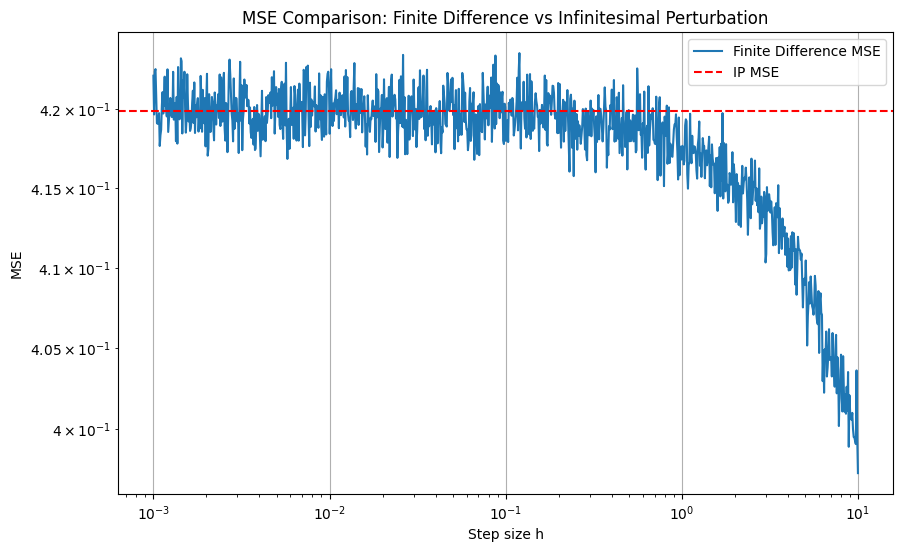

In [6]:
h_range = np.logspace(-3, 1, 1000)
mse_FD = np.zeros(1000)
mse_IP = np.zeros(1000)

np.random.seed(20)

for i in range(1000):
    _, var_estimate_FD = delta_BS_MC_FD(0, S0, K, T, r, sigma, N, h_range[i])
    bias_squared = (h_range[i]**2 * speed / 24)**2
    mse_FD[i] = bias_squared + var_estimate_FD

    _, var_estimate_IP = delta_BS_MC_IP(0, S0, K, T, r, sigma, N)
    mse_IP[i] = var_estimate_IP

plt.figure(figsize=(10, 6))
plt.loglog(h_range, mse_FD, label='Finite Difference MSE')
plt.axhline(y=np.mean(mse_IP), color='r', linestyle='--', label='IP MSE')
plt.xlabel('Step size h')
plt.ylabel('MSE')
plt.legend()
plt.title('MSE Comparison: Finite Difference vs Infinitesimal Perturbation')
plt.grid(True)
plt.show()

Finally, we want to use the likelihood ratio method to compute an option delta. To introduce some variety, we will not consider a European call option but a binary call option with strike $K$ and payoff $1_{\{S(T) \geq K\}}$.

**Task 1.6**: Write a function `delta_binary_BS_MC_LR(t, St, K, T, r, sigma, N)` that performs the likelihood ratio method for the computation of the delta of the binary call option. In other words, the function should simulate $f(X_n) \frac{d\log(g_{S(t)}(X_n))}{ds}$ with $N(\log(S(t)) / \sqrt{\sigma^2 T}, 1)$-distributed random variables $X_n$ for \begin{equation} f(x) = e^{-r(T-t)}1_{\Big\lbrace\exp( (r− \sigma^2 / 2)(T-t) + \sigma \sqrt{T-t} x) \geq K\Big\rbrace} \quad \text{and}\quad\frac{d\log(g_s(x))}{ds} = \frac{x}{s\sigma \sqrt{T-t}} - \frac{\log s}{s \sigma^2 T}.\end{equation} The function should take the number $N$ of simulations as an input argument and should return both the likelihood ratio estimator for the delta and the sample variance of this estimator.

*Useful Python commands*: `np.random.normal`, `np.exp`, `np.sqrt`, `np.log`, `np.var`, `np.mean`

In [7]:
def delta_binary_BS_MC_LR(t, St, K, T, r, sigma, N):
    dt = T - t
    sqrt_dt = np.sqrt(dt)
    
    # Generate X_n ~ N(log(S(t))/sqrt(sigma^2 T), 1)
    mu_X = np.log(St) / (sigma * np.sqrt(T))
    X = np.random.normal(mu_X, 1, N)
    
    # f(x) calculation
    ST = np.exp((r - sigma**2/2) * dt + sigma * sqrt_dt * X)
    f = np.exp(-r * dt) * (ST >= K).astype(float)
    
    # dlog(g_s(x))/ds calculation
    dlog_ds = X / (St * sigma * sqrt_dt) - np.log(St) / (St * sigma**2 * T)
    
    Z_prime = f * dlog_ds
    var_estimator = np.var(Z_prime, ddof=1)
    return Z_prime.mean(), var_estimator

We now want to visualize how the MSE of the likelihood ratio estimator for the delta of the binary call depends on the level of the strike $K$.

**Task 1.7**: Define an array `K_range` containing 1000 equally spaced values of the strike $K$ between 10 and 300. Then use a for-loop to compute the MSE (i.e. the sample variance) of the likelihood ratio estimator of the binary call option delta at time 0 for each value of $K$ in the array `K_range`. Plot the MSE values against the values of $K$ and interpret your result using a comment.

*Useful Python commands*: `np.linspace`

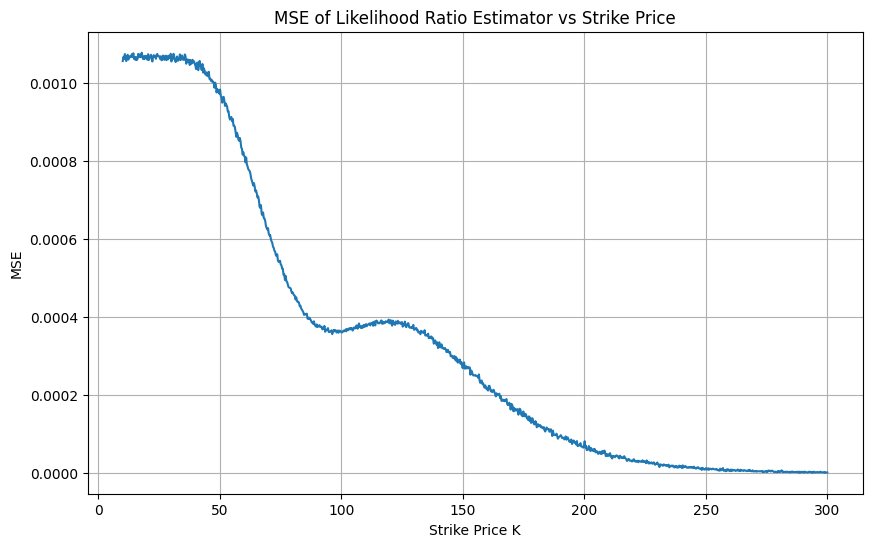

In [8]:
K_range = np.linspace(10, 300, 1000)
mse_LR = np.zeros(1000)

for i in range(1000):
    _, var_estimate_LR = delta_binary_BS_MC_LR(0, S0, K_range[i], T, r, sigma, N)
    mse_LR[i] = var_estimate_LR

plt.figure(figsize=(10, 6))
plt.plot(K_range, mse_LR)
plt.xlabel('Strike Price K')
plt.ylabel('MSE')
plt.title('MSE of Likelihood Ratio Estimator vs Strike Price')
plt.grid(True)
plt.show()

<br>

## Step 2: Computation of American option prices using the Longstaff-Schwartz algorithm

The Longstaff-Schwartz algorithm is a sophisticated method to compute prices of American options using Monte Carlo simulation, which is a highly non-trivial task. The main idea underlying the Longstaff-Schwartz algorithm is to approximate the *continuation value* of the American option by regressing it on a set of basis functions $\ell_0, \ell_1, \dots, \ell_M$ of the Hilbert space $L^2(\mathbb{R}_+, \mathscr{B}_+, \mu)$ with some probability measure $\mu$. Often, one chooses $\ell_k$ to be the *Laguerre polynomials*. In the following, we will choose $M = 3$. We now want to implement the full algorithm given on page 71 of the lecture notes.

In a first step, one needs to simulate $N$ paths of the stock price with a discretization step size $\Delta t = T / M$.

**Task 2.1**: Fill the blank spaces in the code snippet below to simulate $N = 50\,000$ paths of a geometric Brownian motion with $m = 1000$.

*Useful Python commands*: `np.sqrt`

In [9]:
m = 1000
N = 50000
M = 3
dt = T / m

np.random.seed(20)
dWt = np.random.normal(0, np.sqrt(dt), (N, m))
S = np.zeros((N, m + 1))

S[:, 0] = S0
for t in range(1, m + 1):
    S[:, t] = S[:, t - 1] * np.exp((r - sigma**2/2) * dt + sigma * dWt[:, t-1])

**Task 2.2**: Define an array `tau` that is supposed to contain the optimal exercise times $\tau_n$, $n \in \{1, \dots, N\}$. Initialize the array `tau` with $\tau_n \equiv T$. Define another array `g` containing the $N$ values $g_n = (K - S_{n, m})^+$ for  $n \in \{1, \dots, N\}$, which will later be updated to contain the payoffs at the optimal exercise times $\tau_n$.

*Useful Python commands*: `np.repeat`, `np.maximum`

In [10]:
tau = np.repeat(T, N)
g = np.maximum(K - S[:, m], 0)

**Task 2.3**: Fill the blank spaces in the code below, which is supposed to compute the $t$-**loop** section of the algorithm from page 71 of the lecture notes. It stores the output $V_0$ of the algorithm in a variable `V0` and additionally computes the width of a 95\% confidence interval for $V_0$ and stores it in a variable `epsilon_95`.

*Useful Python commands*: The scipy.special command `eval_laguerre(k, x)` evaluates the $k$-th Laguerre polynomial $\ell_k(x)$ at some point $x$. The command `np.linalg.lstsq(x, y)[0]` performs the least-squares linear regression $y_n = \sum_{k=0}^M a_k x_{n, k}$ for a given array `y` containing $y_n$ and a given matrix `x` containing $x_{n, k}$ and returns the array of $a_k$ values.

*Useful Python commands*: `np.exp`, `np.maximum`

In [11]:
for i in range(m - 1, 0, -1):
    ITM = np.where(K - S[:, i] > 0)[0]  # in-the-money indices
    if ITM.shape[0] == 0:
        continue  # if no path is in the money, skip the iteration
    
    y = np.exp(-r * (tau[ITM] - i * dt)) * g[ITM]
    x = np.vstack([eval_laguerre(k, S[ITM, i]) for k in range(M + 1)]).T
    a = np.linalg.lstsq(x, y, rcond=None)[0]

    continuation_values = (x @ a)
    exercise_check = ITM[np.where(np.maximum(K - S[ITM, i], 0) >= continuation_values)]
    tau[exercise_check] = i * dt
    g[exercise_check] = np.maximum(K - S[exercise_check, i], 0)

V0 = max(np.maximum(K - S0, 0), np.mean(np.exp(-r * tau) * g))
epsilon_95 = 1.96 * np.sqrt(np.var(np.exp(-r * tau) * g, ddof=1) / N)

The code snippet below contains a function `american_put_CRR(S0, K, T, r, sigma, M)` that computes the price of an American option in the CRR binomial model with `M` steps. We now want to use this function to compute a reference value for the American option price so we can test the Longstaff-Schwartz algorithm above.

**Task 2.4**: Use the function `american_put_CRR` to define a variable `V0_CRR` that contains the price $V(0)$ of the American call option with strike $K = 100$ and all other variables as set in the beginning of the notebook in the CRR model with $M = 10000$ steps. Then print the CRR reference price next to the Longstaff-Schwartz option price stored in the variable `V0` and also print the 95\% error of the Longstaff-Schwartz estimate stored in the variable `epsilon_95`. Interpret and assess your result using a comment.

In [12]:
def american_put_CRR(S0, K, T, r, sigma, M): 
    delta_t = T / M
    alpha = np.exp(r * delta_t)
    beta = 1 / 2 * (alpha ** (-1) + alpha * np.exp(sigma ** 2 * delta_t))
    u = beta + np.sqrt(beta ** 2 - 1)
    d = 1 / u
    q = (alpha - d) / (u - d)

    value = np.maximum(K - S0 * u ** (2 * np.arange(M + 1) - M), 0)
    for i in range(M - 1, -1, -1):
        upsteps, downsteps = value[1:], value[:-1]
        value = alpha ** (-1) * (q * upsteps + (1 - q) * downsteps)
        payoffs = np.maximum(K - S0 * u ** (2 * np.arange(i + 1) - i), 0)
        value = np.maximum(value, payoffs)
    return value[0]

V0_CRR = american_put_CRR(S0, K, T, r, sigma, 10000)
print('CRR reference price: {:.5f}, MC price: {:.5f}, 95% error: {:.5f}'.format(V0_CRR, V0, epsilon_95))

CRR reference price: 11.01309, MC price: 11.00147, 95% error: 0.10778


<br>

## Step 3: Computation of European call option price surfaces using the explicit finite difference method

Finite differences methods from Chapter 6 of the lecture are probably the most widely used tools for option pricing in practice because they are totally flexible in the payoff, can be generalized to work for many sophisticated stochastic models and are able to compute the whole surface of option prices across a two-dimensional $(t, S(t))$-grid. In the following, we want to implement the explicit finite differences scheme, which is given in pseudo-code on pages 74-75 of the lecture notes (with zero boundary conditions), for a European call option in the Black-Scholes model. The explicit finite differences scheme has the disadvantage that it becomes numerically instable if the number $m$ of discretized points of the (transformed) stock is chosen too large.

The code snippet below defines the input values $a = -0.7$, $b=0.4$ and $\nu_\max=2000$ for the algorithm.

**Task 3.1**: Define a variable `m` that contains the largest possible integer value of $m$ so that the explicit scheme with the above chosen values for $a$, $b$ and $\nu_\max$ is stable. Recall that the explicit finite differences scheme is stable as long as $\sigma^2 T/(2\nu_\max) < (b−a)^2/(2m^2)$. 

*Useful Python commands*: `int`, `np.sqrt`

In [13]:
a = -0.7
b = 0.4
nu_max = 2000
m = int(np.sqrt(sigma**2 * T * nu_max / (2 * (b - a)**2)))

**Task 3.2**: Define the variables $q$, $\Delta \widetilde x$, $\Delta \widetilde t$ and $\lambda$ from the explicit scheme on pages 74-75 of the lecture notes.

In [14]:
q = 2 * r / sigma**2 - 1
delta_x = (b - a) / m
delta_t = T * sigma**2 / (2 * nu_max)
fidi_lambda = delta_t / (delta_x**2)

**Task 3.3**: Define an array `x` that contains the $m + 1$ equally spaced values $\widetilde x_i = a + i \Delta \widetilde x$ as well as an array `t` that contains the $\nu_\max + 1$ equally spaced values $\widetilde t_i = i \Delta \widetilde t$.

*Useful Python commands*: `np.linspace`

In [15]:
x = np.linspace(a, b, m + 1)
t = np.linspace(0, T * sigma**2 / 2, nu_max + 1)

**Task 3.4**: Initialize a 2D array `w` of shape `(nu_max + 1, m + 1)` containing only zeros that is later supposed to be filled with the solution of the heat equation in transformed variables $\widetilde t_i, \widetilde x_i$. Set the first row of `w` according to the boundary condition $w_i = \max\{e^{\frac{\widetilde x_i}{2}(q + 1)} - e^{\frac{\widetilde x_i}{2} (q - 1)}, 0\}$.

*Useful Python commands*: `np.zeros`, `np.maximum`, `np.exp`

In [16]:
w = np.zeros((nu_max + 1, m + 1))
w[0] = np.maximum(np.exp(x/2 * (q + 1)) - np.exp(x/2 * (q - 1)), 0)

The code snippet below defines the tridiagonal matrix $A = A_{\mathrm{expl}}$ from equation (6.8) of the lecture notes.

**Task 3.5**: Fill the other rows of the matrix `w` using the iterative scheme $w^{(\nu + 1)} = A w^{(\nu)}$.

*Useful Python commands*: `np.matmul`, `np.dot`, `@`

In [17]:
A = np.diag(np.repeat(fidi_lambda, m - 2), -1) + np.diag(np.repeat(1 - 2 * fidi_lambda, m - 1)) + np.diag(np.repeat(fidi_lambda, m - 2), 1)

for nu in range(nu_max):
    w[nu + 1, 1:-1] = A @ w[nu, 1:-1]

**Task 3.6**: Define an array `S` that contains the values $S_i = K e^{\widetilde x_i}$ for $i \in \{1, \dots, m-1\}$. Define another array `t` that contains the values $t_i = T - \frac{2}{\sigma^2} \widetilde t_i$ in ascending order. The code snippet below then proceeds to compute the solution $v(t_i, S_i)$ in original coordinates and plots the surface of $v(t, S(t))$ values across the grid of `S` and `t` values.

*Useful Python commands* `np.exp`

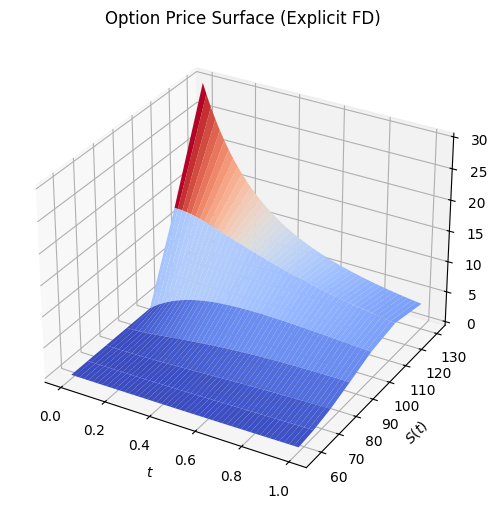

In [18]:
S = K * np.exp(x[1:-1])
t_orig = T - 2 * t / sigma**2

v_S = K * w[::-1, 1:-1] * np.exp(-x[1:-1] / 2 * (q - 1) - sigma**2 / 2 * (T - t_orig[:, np.newaxis]) * ((q - 1)**2 / 4 + q))
S_grid, t_grid = np.meshgrid(S, t_orig)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 8))
ax.plot_surface(t_grid, S_grid, v_S, cmap=plt.cm.coolwarm)
ax.set_xlabel('$t$')
ax.set_ylabel('$S(t)$')
ax.set_title('Option Price Surface (Explicit FD)')
plt.show()

The "call option price surface" depicted above displays some rather strange stylized facts: In particular, it seems that the computed option prices $V(t)$ are not even monotonically increasing in $S(t)$, which is clearly wrong. The reason for this is that we (wrongly) assumed zero boundary conditions for $S(t) \to \infty$, which we want to change now.

**Task 3.7**: Fill the blank spaces in the function below to incorporate the necessary boundary condition $v(t, S(t)) \approx S(t) - K e^{-r(T - t)}$ for $S(t) \gg K$ for the explicit finite differences scheme.

*Useful Python commands*: `np.linspace`, `np.exp`, `np.zeros`, `np.maximum`, `np.matmul`, `np.dot`, `@`

In [19]:
def call_BS_FiDi_explicit(r, sigma, a, b, m, nu_max, T, K):
    q = 2 * r / sigma**2 - 1
    delta_x = (b - a) / m
    delta_t = T * sigma**2 / (2 * nu_max)
    fidi_lambda = delta_t / (delta_x**2)
    
    x = np.linspace(a, b, m + 1)
    t_tilde = np.linspace(0, T * sigma**2 / 2, nu_max + 1)
    
    # Boundary condition function
    r2 = lambda t, x: np.exp(x) - np.exp(-r * (T - t))
    
    w = np.zeros((nu_max + 1, m + 1))
    w[0] = np.maximum(np.exp(x/2 * (q + 1)) - np.exp(x/2 * (q - 1)), 0)
    
    A = np.diag(np.repeat(fidi_lambda, m - 2), -1) + np.diag(np.repeat(1 - 2 * fidi_lambda, m - 1)) + np.diag(np.repeat(fidi_lambda, m - 2), 1)
    
    for nu in range(nu_max):
        # Apply boundary conditions
        w[nu + 1, 0] = 0  # S -> 0
        w[nu + 1, -1] = r2(T - 2 * t_tilde[nu + 1] / sigma**2, b)  # S -> infinity
        
        w[nu + 1, 1:-1] = A @ w[nu, 1:-1]

    S = K * np.exp(x[1:-1])
    t_orig = T - 2 * t_tilde / sigma**2
    V = K * w[::-1, 1:-1] * np.exp(-x[1:-1] / 2 * (q - 1) - sigma**2 / 2 * (T - t_orig[:, np.newaxis]) * ((q - 1)**2 / 4 + q))
    return t_orig, S, V

**Task 3.8**: Use the above function `call_BS_FiDi_explicit` with the same input arguments as used before to compute the correct option pricing surface and plot it as in Task 3.6. Interpret your result using a comment. Afterwards, try out some different values of $m$ that are larger than the one that we derived in Task 3.1. What can you observe in the picture?

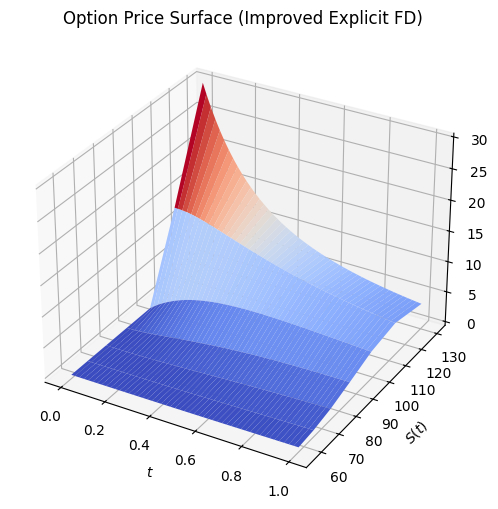

In [20]:
t, S, v_S = call_BS_FiDi_explicit(r, sigma, a, b, m, nu_max, T, K)

S_grid, t_grid = np.meshgrid(S, t)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 8))
ax.plot_surface(t_grid, S_grid, v_S, cmap=plt.cm.coolwarm)
ax.set_xlabel('$t$')
ax.set_ylabel('$S(t)$')
ax.set_title('Option Price Surface (Improved Explicit FD)')
plt.show()

<br>

## Step 4: Computation of European call option price surfaces using the Crank-Nicolson method

The instability that arises in the explicit finite difference scheme for values of $m$ that are too large can be avoided by using a more sophisticated finite differences scheme like the Crank-Nicolson method. To implement the Crank-Nicolson method, we need some fast method to solve linear systems of equations with tridiagonal coefficient matrices.

**Task 4.1**: Write a function `triagmatrix_inversion(alpha, beta, gamma, b)` that solves the linear system $Ax = b$, where the coefficient matrix $A$ is tridiagonal. The function should receive numpy arrays `alpha`, `beta`, `gamma` and `b` as input arguments containing the constants $\alpha_1, \dots, \alpha_n$, $\beta_1, \dots, \beta_{n-1}$, $\gamma_2, \dots, \gamma_n$ and $b_1, \dots, b_n$, respectively. The function should then perform the tridiagonal matrix inversion algorithm from page 78 of the lecture notes.

In [21]:
def triagmatrix_inversion(alpha, beta, gamma, b):
    n = len(alpha)
    # Forward elimination
    w = np.zeros(n-1)
    g = np.zeros(n)
    
    w[0] = gamma[1] / alpha[0]
    g[0] = b[0] / alpha[0]
    
    for i in range(1, n):
        if i < n-1:
            w[i] = gamma[i+1] / (alpha[i] - beta[i-1] * w[i-1])
        g[i] = (b[i] - beta[i-1] * g[i-1]) / (alpha[i] - beta[i-1] * w[i-1])
    
    # Backward substitution
    x = np.zeros(n)
    x[-1] = g[-1]
    for i in range(n-2, -1, -1):
        x[i] = g[i] - w[i] * x[i+1]
    
    return x

**Task 4.2**: Fill the blank spaces in the code below to implement a function `call_BS_FiDi_CN(r, sigma, a, b, m, nu_max, T, K)` that computes the 2-dimensional option price surface $V(t)$ across the $(t, S(t))$ grid in the same way as the function `call_BS_FiDi_explicit` in Task 3.7, but this time using the Crank-Nicolson scheme instead of the explicit scheme. The function should incorporate appropriate boundary conditions for $S(t) \gg K$ to the algorithm.

*Useful Python commands*: `np.linspace`, `np.exp`, `np.zeros`, `np.maximum`

In [22]:
def call_BS_FiDi_CN(r, sigma, a, b, m, nu_max, T, K):
    q = 2 * r / sigma**2 - 1
    delta_x = (b - a) / m
    delta_t = T * sigma**2 / (2 * nu_max)
    fidi_lambda = delta_t / (delta_x**2)
    
    x = np.linspace(a, b, m + 1)
    t_tilde = np.linspace(0, T * sigma**2 / 2, nu_max + 1)
    
    # Boundary condition function
    r2 = lambda t, x: np.exp(x) - np.exp(-r * (T - t))
    
    w = np.zeros((nu_max + 1, m + 1))
    w[0] = np.maximum(np.exp(x/2 * (q + 1)) - np.exp(x/2 * (q - 1)), 0)
    
    # Construct matrices for Crank-Nicolson
    alpha_main = 1 + fidi_lambda
    alpha_off = -fidi_lambda / 2
    
    # A matrix (I + lambda/2 * A)
    A_diag = np.repeat(alpha_main, m - 1)
    A_off = np.repeat(alpha_off, m - 2)
    A = np.diag(A_diag) + np.diag(A_off, -1) + np.diag(A_off, 1)
    
    # B matrix (I - lambda/2 * A)
    B_diag = np.repeat(1 - fidi_lambda, m - 1)
    B_off = np.repeat(fidi_lambda / 2, m - 2)
    B = np.diag(B_diag) + np.diag(B_off, -1) + np.diag(B_off, 1)
    
    for nu in range(nu_max):
        # Apply boundary conditions
        w[nu + 1, 0] = 0  # S -> 0
        w[nu + 1, -1] = r2(T - 2 * t_tilde[nu + 1] / sigma**2, b)  # S -> infinity
        
        # Solve A w^{nu+1} = B w^{nu} for interior points
        b_vec = B @ w[nu, 1:-1]
        w[nu + 1, 1:-1] = np.linalg.solve(A, b_vec)

    S = K * np.exp(x[1:-1])
    t_orig = T - 2 * t_tilde / sigma**2
    V = K * w[::-1, 1:-1] * np.exp(-x[1:-1] / 2 * (q - 1) - sigma**2 / 2 * (T - t_orig[:, np.newaxis]) * ((q - 1)**2 / 4 + q))
    return t_orig, S, V

**Task 4.3**: Evaluate your function `call_BS_FiDi_CN` on the same input arguments as before but this time with $m = 1000$ to compute the option pricing surface and plot it as in Task 3.6. Interpret your result using a comment and compare it to the result of Task 3.8.

In [ ]:
m = 1000
t, S, v_S = call_BS_FiDi_CN(r, sigma, a, b, m, nu_max, T, K)

S_grid, t_grid = np.meshgrid(S, t)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 8))
ax.plot_surface(t_grid, S_grid, v_S, cmap=plt.cm.coolwarm)
ax.set_xlabel('$t$')
ax.set_ylabel('$S(t)$')
ax.set_title('Option Price Surface (Crank-Nicolson)')
plt.show()

<br>

## Step 5: Richardson extrapolation for American options in the binomial model

Richardson extrapolation is a widely used tool to reduce the bias of option pricing computations. It can be used in Monte Carlo simulations where the simulation scheme for the underlying model (like the Euler scheme or the Milshtein scheme) introduces a bias but it is also often used in conjunction with finite difference methods or binomial trees where the discretization of the employed grid or tree introduces a pricing error. In the following, we want to use Richardson extrapolation for the computation of American options in the binomial model.

The code snippet below contains a function `american_put_CRR_anchored` that computes the price of an American put option in the binomial model. It uses the strike-anchored parameterization of the binomial tree from Step 1 of the Week 03 notebook.

In [ ]:
def american_put_CRR_anchored(S0, K, T, r, sigma, M):
    delta_t = T / M
    c = (K / S0) ** (2 / M)
    alpha = np.exp(r * delta_t)
    beta = 1 / 2 * (c / alpha + alpha * np.exp(sigma**2 * delta_t))
    u = beta + np.sqrt(beta**2 - c)
    d = c / u
    q = (np.exp(r * delta_t) - d) / (u - d)

    value = np.maximum(K - S0 * u ** (2 * np.arange(M + 1) - M) * c ** np.arange(M, -1, -1), 0)
    for i in range(M - 1, -1, -1):
        upsteps, downsteps = value[1:], value[:-1]
        value = alpha ** (-1) * (q * upsteps + (1 - q) * downsteps)
        payoffs = np.maximum(K - S0 * u ** (2 * np.arange(i + 1) - i) * c ** np.arange(i, -1, -1), 0)
        value = np.maximum(value, payoffs)
    return value[0]

First we want to calculate a reference value for the "true" American put price in the Black-Scholes model. 

**Task 5.1**: Define $S(0) = 80$. Use the function `american_put_CRR_anchored` with $M = 50\,000$ and all other input variables as before to calculate the reference value $V_{\mathrm{ref}}(0)$ and store it in a variable `V0_ref`.

In [ ]:
S0 = 80
V0_ref = american_put_CRR_anchored(S0, K, T, r, sigma, 50000)

Before we use Richardson extrapolation, we have to examine the behaviour of the pricing error of the scheme.

**Task 5.2**: Use the function `american_put_CRR_anchored` in a for-loop to calculate the American put prices $V_{M}(0)$ in the binomial model with the number $M$ of time steps taking the values $M = 50, 55, 60, \dots, 495, 500$. Store these prices in an array `prices_test`. Afterwards, plot the difference between the prices $V_M(0)$ stored in the array `prices_test` and the reference price $V_{\mathrm{ref}}(0)$ stored in the variable `V0_ref` against $M$.

In [ ]:
M_values = np.arange(50, 501, 5)
prices_test = np.zeros(len(M_values))

for i, M in enumerate(M_values):
    prices_test[i] = american_put_CRR_anchored(S0, K, T, r, sigma, M)

plt.figure(figsize=(10, 6))
plt.plot(M_values, prices_test - V0_ref)
plt.xlabel('Number of Steps M')
plt.ylabel('Price Error')
plt.title('Pricing Error vs Number of Steps')
plt.grid(True)
plt.show()

The above figure shows that for even $M$, the binomial model price $V_M(0)$ overshoots the "true" reference price $V_{\mathrm{ref}}(0)$ of the American option, while for odd $M$ the price $V_M(0)$ undershoots the reference price. This suggests that it makes sense to use Richardson extrapolation in the sense that one considers the linear combination $2V_{4M}(0) - V_{2M}(0)$ (or, alternatively, the linear combination $2V_{4M + 1}(0) - V_{2M + 1}(0)$). We now want to examine how much faster this extrapolated value converges to the "true" price as $M \to \infty$ compared to the crude estimates.

**Task 5.3**: Use the function `american_put_CRR_anchored` in a for-loop to calculate the American put prices $V_{2M}(0)$ in the binomial model with the number $M$ of time steps taking the values $M = 20, 40, 60, \dots, 2480, 2500$. Store these prices in an array `prices`. Afterwards, use the function `american_put_CRR_anchored` in a for-loop to calculate the linear combinations $2V_{4M}(0) - V_{2M}(0)$ and store them in an array `prices_richardson`.

In [ ]:
M_values_rich = np.arange(20, 2501, 20)
prices_crude = np.zeros(len(M_values_rich))
prices_richardson = np.zeros(len(M_values_rich))

for i, M in enumerate(M_values_rich):
    V_2M = american_put_CRR_anchored(S0, K, T, r, sigma, 2 * M)
    V_4M = american_put_CRR_anchored(S0, K, T, r, sigma, 4 * M)
    
    prices_crude[i] = V_2M
    prices_richardson[i] = 2 * V_4M - V_2M

**Task 5.4**: Plot the crude price estimates stored in the array `prices_crude` against $M = 40, 80, 120, \dots, 4960, 5000$. Afterwards, plot the Richardson extrapolations stored in the array `prices_richardson` against $M = 40, 80, 120, \dots, 4960, 5000$. Use the function `plt.semilogx` instead of `plt.plot` to obtain a logarithmic spacing of the $x$ axis. Draw a horizontal line at the height of the reference price $V_{\mathrm{ref}}(0)$ stored in the variable `V0_ref` and interpret your result using a comment.

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogx(2 * M_values_rich, prices_crude - V0_ref, label='Crude Estimate Error')
plt.axhline(y=0, color='r', linestyle='--', label='Reference')
plt.ylabel('Error')
plt.title('Convergence: Crude Estimate')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(2 * M_values_rich, prices_richardson - V0_ref, label='Richardson Extrapolation Error')
plt.axhline(y=0, color='r', linestyle='--', label='Reference')
plt.xlabel('Number of Steps M')
plt.ylabel('Error')
plt.title('Convergence: Richardson Extrapolation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()